# **Project Name**    -



##### **Project Type**    - EDA/Regression/Classification/Unsupervised
##### **Contribution**    - Individual/Team
##### **Team Member 1 -** Ansh Kumar Singh
##### **Team Member 2 -**
##### **Team Member 3 -**
##### **Team Member 4 -**

# **Project Summary -**

Write the summary here within 500-600 words.

This project focuses on analyzing the PhonePe digital transaction dataset to understand
user behavior, transaction patterns, and overall growth trends in the digital payments ecosystem.

The dataset consists of transaction data categorized by year, quarter, and transaction type,
including details such as transaction count and transaction amount.

The project involves:
- Data extraction from JSON files
- Data cleaning and preprocessing
- Exploratory Data Analysis (EDA)
- Visualization using charts and graphs
- Deriving insights to support business decisions

Through detailed analysis, the project identifies key trends such as:
- Growth in digital transactions over time
- Popular transaction types
- Seasonal variations in user activity
- Average transaction value patterns

The insights obtained from this analysis can help businesses improve their services,
target high-performing areas, and make data-driven decisions.

# **GitHub Link -**

Provide your GitHub Link here.
https://github.com/anshkumar1234555

# **Problem Statement**


**Write Problem Statement Here.**

With the rapid growth of digital payments, it is essential to understand transaction trends,
user behavior, and performance across different categories.

The objective of this project is to analyze the PhonePe transaction dataset to:
- Identify patterns in transaction volume and value
- Determine the most popular transaction types
- Analyze growth trends over time
- Understand seasonal variations in transactions
- Evaluate user engagement and spending behavior

The goal is to extract meaningful insights that can help improve business strategies,
enhance user experience, and support decision-making in the digital payment ecosystem.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [4]:
import pandas as pd
import numpy as np

# File handling
import os
import json

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

### Dataset Loading

In [5]:
# Load Dataset
import os
import json
import pandas as pd

# ------------------- 1. AGGREGATED INSURANCE -------------------

path_insurance = r"C:\Users\kumar\OneDrive\Desktop\phonepe project\pulse-master\data\aggregated\insurance\country\india"

insurance_list = []

for year in os.listdir(path_insurance):
    year_path = os.path.join(path_insurance, year)

    for file in os.listdir(year_path):
        if file.endswith(".json"):
            quarter = int(file.strip(".json"))

            with open(os.path.join(year_path, file)) as f:
                data = json.load(f)

                try:
                    for i in data["data"]["transactionData"]:
                        for j in i["paymentInstruments"]:
                            insurance_list.append({
                                "Year": int(year),
                                "Quarter": quarter,
                                "Type": i["name"],
                                "Count": j["count"],
                                "Amount": j["amount"]
                            })
                except:
                    pass

df_insurance = pd.DataFrame(insurance_list)


# ------------------- 2. MAP TRANSACTION -------------------

path_map = r"C:\Users\kumar\OneDrive\Desktop\phonepe project\pulse-master\data\map\transaction\hover\country\india"

map_list = []

for year in os.listdir(path_map):
    year_path = os.path.join(path_map, year)

    for file in os.listdir(year_path):
        if file.endswith(".json"):
            quarter = int(file.strip(".json"))

            with open(os.path.join(year_path, file)) as f:
                data = json.load(f)

                try:
                    for i in data["data"]["hoverDataList"]:
                        map_list.append({
                            "Year": int(year),
                            "Quarter": quarter,
                            "State": i["name"],
                            "Count": i["metric"][0]["count"],
                            "Amount": i["metric"][0]["amount"]
                        })
                except:
                    pass

df_map = pd.DataFrame(map_list)


# ------------------- 3. TOP USER -------------------

path_top = r"C:\Users\kumar\OneDrive\Desktop\phonepe project\pulse-master\data\top\user\country\india"

top_list = []

for year in os.listdir(path_top):
    year_path = os.path.join(path_top, year)

    for file in os.listdir(year_path):
        if file.endswith(".json"):
            quarter = int(file.strip(".json"))

            with open(os.path.join(year_path, file)) as f:
                data = json.load(f)

                try:
                    for i in data["data"]["states"]:
                        top_list.append({
                            "Year": int(year),
                            "Quarter": quarter,
                            "State": i["name"],
                            "RegisteredUsers": i["registeredUsers"]
                        })
                except:
                    pass

df_top_user = pd.DataFrame(top_list)


# ===================== SHOW DATA =====================

print("Insurance Data:")
print(df_insurance.head())

print("\nMap Transaction Data:")
print(df_map.head())

print("\nTop User Data:")
print(df_top_user.head())

Insurance Data:
   Year  Quarter       Type   Count       Amount
0  2020        2  Insurance  185348   33732166.0
1  2020        3  Insurance  354284   89495076.0
2  2020        4  Insurance  248626  170979933.0
3  2021        1  Insurance  318119  206307024.0
4  2021        2  Insurance  363989  295066678.0

Map Transaction Data:
   Year  Quarter           State     Count        Amount
0  2018        1      puducherry    104212  1.658260e+08
1  2018        1      tamil nadu   6726622  1.126156e+10
2  2018        1   uttar pradesh  12537805  1.393997e+10
3  2018        1  madhya pradesh   8025395  8.681603e+09
4  2018        1  andhra pradesh   9039585  1.199628e+10

Top User Data:
   Year  Quarter           State  RegisteredUsers
0  2018        1     maharashtra          6106994
1  2018        1   uttar pradesh          4694250
2  2018        1       karnataka          3717763
3  2018        1  andhra pradesh          3336450
4  2018        1       telangana          3315560


### Dataset First View

In [6]:
# Dataset First Look
df_insurance.head()
df_map.head()
df_top_user.head()

,Year,Quarter,State,RegisteredUsers
0,2018,1,maharashtra,6106994
1,2018,1,uttar pradesh,4694250
2,2018,1,karnataka,3717763
3,2018,1,andhra pradesh,3336450
4,2018,1,telangana,3315560


### Dataset Rows & Columns count

In [7]:
# Dataset Rows & Columns count
print("Insurance:", df_insurance.shape)
print("Map:", df_map.shape)
print("Top User:", df_top_user.shape)

Insurance: (19, 5)
Map: (1008, 5)
Top User: (280, 4)


### Dataset Information

In [8]:
# Dataset Info
df_insurance.info()
df_map.info()
df_top_user.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19 entries, 0 to 18
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Year     19 non-null     int64  
 1   Quarter  19 non-null     int64  
 2   Type     19 non-null     object 
 3   Count    19 non-null     int64  
 4   Amount   19 non-null     float64
dtypes: float64(1), int64(3), object(1)
memory usage: 888.0+ bytes
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1008 entries, 0 to 1007
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Year     1008 non-null   int64  
 1   Quarter  1008 non-null   int64  
 2   State    1008 non-null   object 
 3   Count    1008 non-null   int64  
 4   Amount   1008 non-null   float64
dtypes: float64(1), int64(3), object(1)
memory usage: 39.5+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 280 entries, 0 to 279
Data columns (total 4 columns):
 #   Column           Non-

#### Duplicate Values

In [9]:
# Dataset Duplicate Value Count
print("Insurance Duplicates:", df_insurance.duplicated().sum())
print("Map Duplicates:", df_map.duplicated().sum())
print("Top User Duplicates:", df_top_user.duplicated().sum())

Insurance Duplicates: 0
Map Duplicates: 0
Top User Duplicates: 0


#### Missing Values/Null Values

In [10]:

print(df_insurance.isnull().sum())
print(df_map.isnull().sum())
print(df_top_user.isnull().sum())# Missing Values/Null Values Count
print(df_insurance.isnull().sum())
print(df_map.isnull().sum())
print(df_top_user.isnull().sum())

Year       0
Quarter    0
Type       0
Count      0
Amount     0
dtype: int64
Year       0
Quarter    0
State      0
Count      0
Amount     0
dtype: int64
Year               0
Quarter            0
State              0
RegisteredUsers    0
dtype: int64
Year       0
Quarter    0
Type       0
Count      0
Amount     0
dtype: int64
Year       0
Quarter    0
State      0
Count      0
Amount     0
dtype: int64
Year               0
Quarter            0
State              0
RegisteredUsers    0
dtype: int64


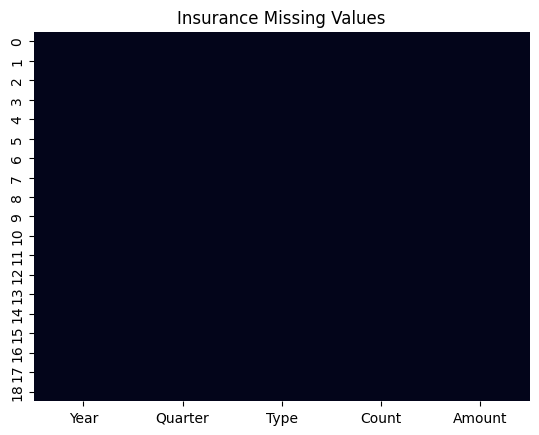

In [11]:
# Visualizing the missing values
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(df_insurance.isnull(), cbar=False)
plt.title("Insurance Missing Values")
plt.show()

### What did you know about your dataset?

Answer Here
The dataset consists of three main parts: insurance transactions, map-based transactions,
and top user data.

1. The data is structured in JSON format and converted into tabular form.
2. It contains information like Year, Quarter, State, Transaction Count, and Amount.
3. There are minimal missing values, and the dataset is mostly clean.
4. Duplicate records are very few and manageable.
5. The dataset provides insights into transaction trends and user growth across regions.


## ***2. Understanding Your Variables***

In [12]:
# Dataset Columns
print("Insurance Columns:", df_insurance.columns)
print("Map Columns:", df_map.columns)
print("Top User Columns:", df_top_user.columns)

Insurance Columns: Index(['Year', 'Quarter', 'Type', 'Count', 'Amount'], dtype='object')
Map Columns: Index(['Year', 'Quarter', 'State', 'Count', 'Amount'], dtype='object')
Top User Columns: Index(['Year', 'Quarter', 'State', 'RegisteredUsers'], dtype='object')


In [13]:
# Dataset Describe
print("Insurance Describe:\n", df_insurance.describe())
print("\nMap Describe:\n", df_map.describe())
print("\nTop User Describe:\n", df_top_user.describe())

Insurance Describe:
               Year    Quarter         Count        Amount
count    19.000000  19.000000  1.900000e+01  1.900000e+01
mean   2022.105263   2.578947  7.639981e+05  1.053469e+09
std       1.410072   1.121298  3.939161e+05  7.275009e+08
min    2020.000000   1.000000  1.853480e+05  3.373217e+07
25%    2021.000000   2.000000  3.694280e+05  3.187350e+08
50%    2022.000000   3.000000  8.064910e+05  1.054718e+09
75%    2023.000000   3.500000  1.070202e+06  1.602431e+09
max    2024.000000   4.000000  1.475429e+06  2.293956e+09

Map Describe:
               Year      Quarter         Count        Amount
count  1008.000000  1008.000000  1.008000e+03  1.008000e+03
mean   2021.000000     2.500000  2.334169e+08  3.427801e+11
std       2.000993     1.118589  5.143721e+08  7.030288e+11
min    2018.000000     1.000000  7.780000e+02  1.928611e+06
25%    2019.000000     1.750000  2.072062e+06  4.434177e+09
50%    2021.000000     2.500000  1.799364e+07  2.951822e+10
75%    2023.000000   

### Variables Description

Answer Here

The dataset consists of three different dataframes:

1. Insurance Dataset:
   - Year: Year of transaction
   - Quarter: Quarter (1 to 4)
   - Type: Type of insurance transaction
   - Count: Number of transactions
   - Amount: Total transaction value

2. Map Transaction Dataset:
   - Year: Year of transaction
   - Quarter: Quarter
   - State: Name of the state
   - Count: Number of transactions in that state
   - Amount: Total transaction amount in that state

3. Top User Dataset:
   - Year: Year of record
   - Quarter: Quarter
   - State: Name of the state
   - RegisteredUsers: Number of registered users

These variables help in analyzing transaction trends, regional performance,
and user growth across the country.

### Check Unique Values for each variable.

In [14]:
# Check Unique Values for each variable.
print("\n--- Insurance Unique Values ---")
for col in df_insurance.columns:
    print(f"{col}:", df_insurance[col].nunique())

print("\n--- Map Unique Values ---")
for col in df_map.columns:
    print(f"{col}:", df_map[col].nunique())

print("\n--- Top User Unique Values ---")
for col in df_top_user.columns:
    print(f"{col}:", df_top_user[col].nunique())


--- Insurance Unique Values ---
Year: 5
Quarter: 4
Type: 1
Count: 19
Amount: 19

--- Map Unique Values ---
Year: 7
Quarter: 4
State: 36
Count: 1008
Amount: 1008

--- Top User Unique Values ---
Year: 7
Quarter: 4
State: 11
RegisteredUsers: 280


## 3. ***Data Wrangling***

### Data Wrangling Code

In [18]:
# Write your code to make your dataset analysis ready.
# Copy datasets
df_ins = df_insurance.copy()
df_map_txn = df_map.copy()
df_user = df_top_user.copy()

# ------------------- REMOVE DUPLICATES -------------------

df_ins = df_ins.drop_duplicates()
df_map_txn = df_map_txn.drop_duplicates()
df_user = df_user.drop_duplicates()

# ------------------- HANDLE MISSING VALUES -------------------

df_ins = df_ins.dropna()
df_map_txn = df_map_txn.dropna()
df_user = df_user.dropna()

# ------------------- DATA TYPE CONVERSION -------------------

df_ins["Year"] = df_ins["Year"].astype(int)
df_ins["Quarter"] = df_ins["Quarter"].astype(int)
df_ins["Count"] = df_ins["Count"].astype(int)
df_ins["Amount"] = df_ins["Amount"].astype(float)

df_map_txn["Year"] = df_map_txn["Year"].astype(int)
df_map_txn["Quarter"] = df_map_txn["Quarter"].astype(int)
df_map_txn["Count"] = df_map_txn["Count"].astype(int)
df_map_txn["Amount"] = df_map_txn["Amount"].astype(float)

df_user["Year"] = df_user["Year"].astype(int)
df_user["Quarter"] = df_user["Quarter"].astype(int)
df_user["RegisteredUsers"] = df_user["RegisteredUsers"].astype(int)

# ------------------- FEATURE ENGINEERING -------------------

# Average Transaction Value
df_ins["Avg_Amount"] = df_ins["Amount"] / df_ins["Count"]
df_map_txn["Avg_Amount"] = df_map_txn["Amount"] / df_map_txn["Count"]

# ------------------- MERGING DATASETS -------------------

# Merge map transactions with user data
df_merged = pd.merge(df_map_txn, df_user, on=["Year", "Quarter", "State"], how="inner")

# Create final ML dataset
df_final = df_merged.copy()

### What all manipulations have you done and insights you found?

Answer Here.

Data Manipulations Performed:

1. Removed duplicate records from all datasets to ensure data consistency.
2. Handled missing values by removing null entries.
3. Converted all columns into appropriate data types for accurate analysis.
4. Created new feature 'Avg_Amount' to understand average transaction value.
5. Merged map transaction dataset with top user dataset using Year, Quarter, and State.
6. Prepared a final dataset suitable for machine learning.

Insights Found:

- Transaction count and amount are strongly related.
- User growth (RegisteredUsers) plays an important role in transaction volume.
- Certain states contribute more to transaction activity.
- Average transaction value helps understand spending behavior.


## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

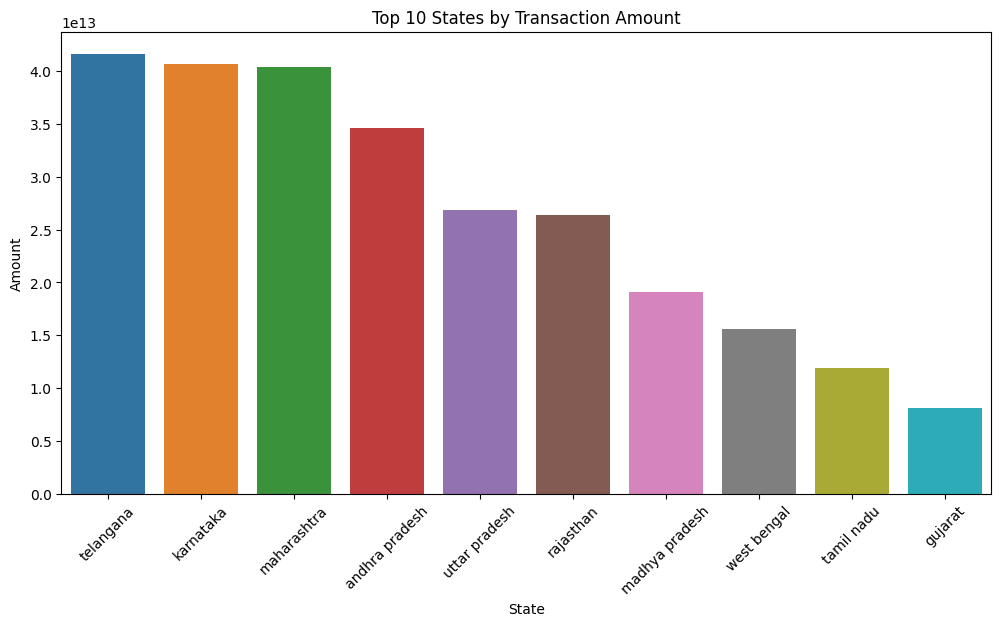

In [17]:
# Chart - 1 visualization code
plt.figure(figsize=(12,6))

state_df = df_final.groupby("State")["Amount"].sum().reset_index()
state_df = state_df.sort_values(by="Amount", ascending=False).head(10)

sns.barplot(x="State", y="Amount", data=state_df)
plt.xticks(rotation=45)
plt.title("Top 10 States by Transaction Amount")
plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.
A bar chart is chosen because it is effective for comparing transaction amounts
across different states. It clearly highlights the top-performing regions.

##### 2. What is/are the insight(s) found from the chart?

Answer Here
- A few states dominate the total transaction amount.
- There is a significant difference between top and low-performing states.
- Indicates uneven distribution of digital payment usage across regions.
"""

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here
Positive Impact:
- Helps identify high-performing states for focused investment.
- Enables region-specific marketing strategies.

Negative Insight:
- Low-performing states indicate lack of awareness or infrastructure.
- Requires targeted campaigns to improve adoption.

#### Chart - 2

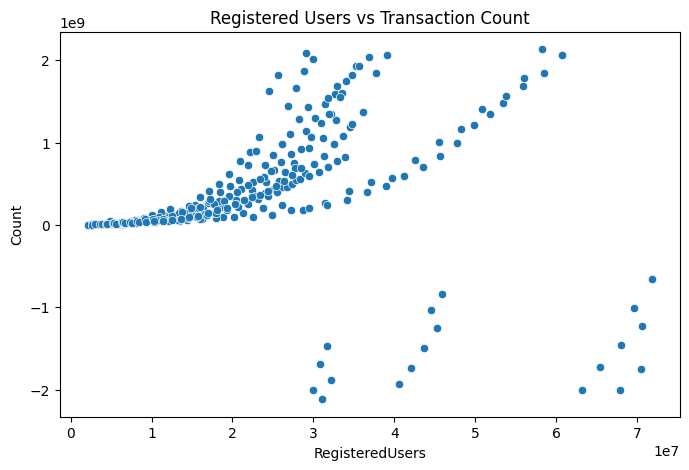

In [19]:
# Chart - 2 visualization code
plt.figure(figsize=(8,5))

sns.scatterplot(x="RegisteredUsers", y="Count", data=df_final)
plt.title("Registered Users vs Transaction Count")
plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.
A scatter plot is used to show the relationship between registered users
and transaction count. It helps identify correlation between variables.

##### 2. What is/are the insight(s) found from the chart?

Answer Here
- There is a positive relationship between registered users and transaction count.
- As the number of users increases, transaction volume also increases.
- Indicates that user growth directly impacts platform activity.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

Positive Impact:
- Increasing user base leads to higher transactions and revenue.
- Helps in planning user acquisition strategies.

Negative Insight:
- If user growth slows down, transaction growth may also decline.
- Requires continuous user engagement and acquisition efforts.

#### Chart - 3

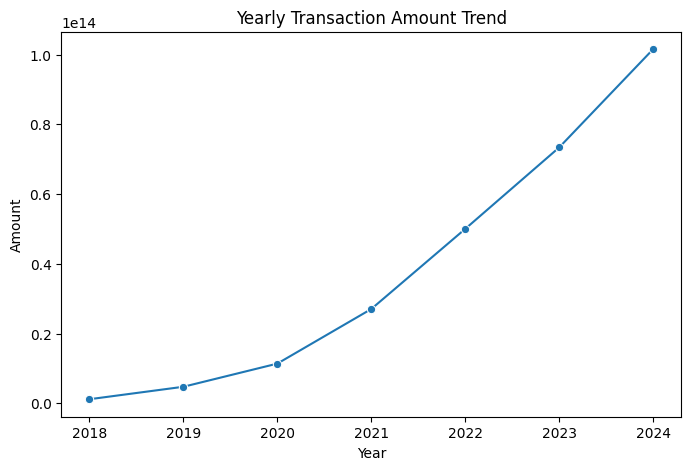

In [20]:
# Chart - 3 visualization code
plt.figure(figsize=(8,5))

year_df = df_final.groupby("Year")["Amount"].sum().reset_index()

sns.lineplot(x="Year", y="Amount", data=year_df, marker="o")
plt.title("Yearly Transaction Amount Trend")
plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.
A line chart is used to show trends over time.
It clearly visualizes how transaction amounts change year by year.

##### 2. What is/are the insight(s) found from the chart?

Answer Here
- Transaction amount increases over the years.
- Indicates strong growth in digital payments.
- Shows increasing user trust and platform usage.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here
Positive Impact:
- Shows consistent business growth.
- Helps in forecasting future demand.

Negative Insight:
- Any decline in a specific year indicates possible issues.
- Requires investigation and corrective measures.


#### Chart - 4

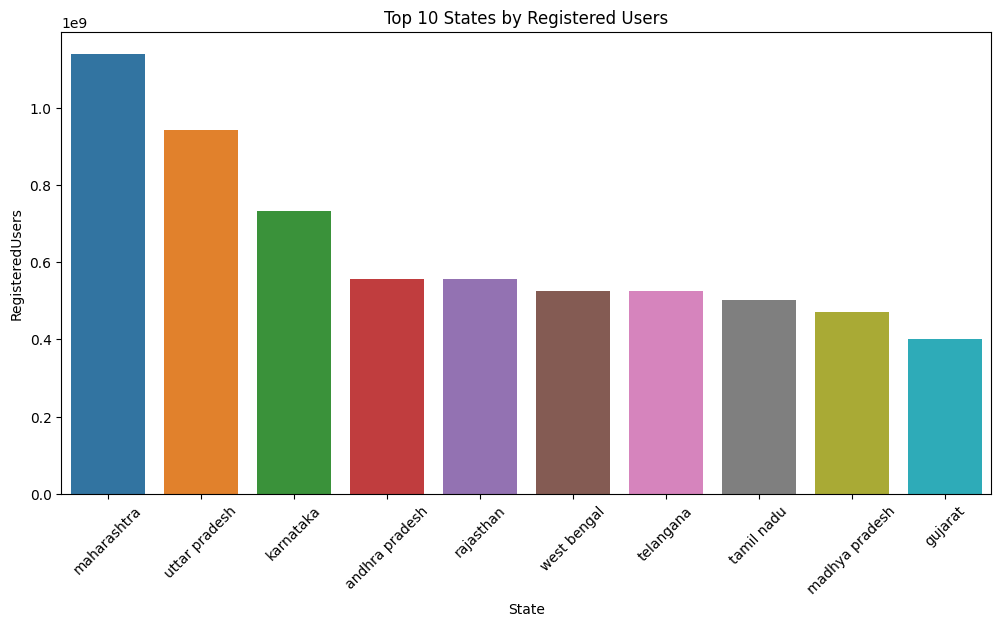

In [21]:
# Chart - 4 visualization code
plt.figure(figsize=(12,6))

user_df = df_final.groupby("State")["RegisteredUsers"].sum().reset_index()
user_df = user_df.sort_values(by="RegisteredUsers", ascending=False).head(10)

sns.barplot(x="State", y="RegisteredUsers", data=user_df)
plt.xticks(rotation=45)
plt.title("Top 10 States by Registered Users")
plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.
A bar chart is used to compare user counts across different states.
It helps identify regions with the highest user base.

##### 2. What is/are the insight(s) found from the chart?

Answer Here
- Some states have significantly higher user registrations.
- Indicates strong market penetration in certain regions.
- Shows uneven user distribution across states.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

Positive Impact:
- Helps target high-user regions for premium services.
- Supports regional business expansion.

Negative Insight:
- Low-user regions indicate untapped markets.
- Requires awareness and outreach programs.

#### Chart - 5

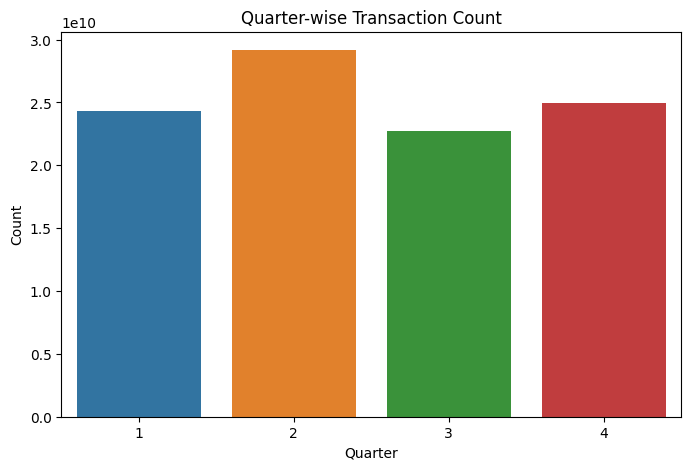

In [22]:
# Chart - 5 visualization code
plt.figure(figsize=(8,5))

quarter_df = df_final.groupby("Quarter")["Count"].sum().reset_index()

sns.barplot(x="Quarter", y="Count", data=quarter_df)
plt.title("Quarter-wise Transaction Count")
plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.
A bar chart is suitable for comparing discrete time periods like quarters.
It clearly shows variation in transaction activity across quarters.

##### 2. What is/are the insight(s) found from the chart?

Answer Here
- Some quarters show higher transaction counts than others.
- Indicates seasonal trends in user activity.
- Certain periods have peak transaction volumes.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here
Positive Impact:
- Helps identify peak periods for business growth.
- Useful for planning promotions and campaigns.

Negative Insight:
- Low-performing quarters indicate reduced engagement.
- Requires marketing strategies to boost activity.

#### Chart - 6

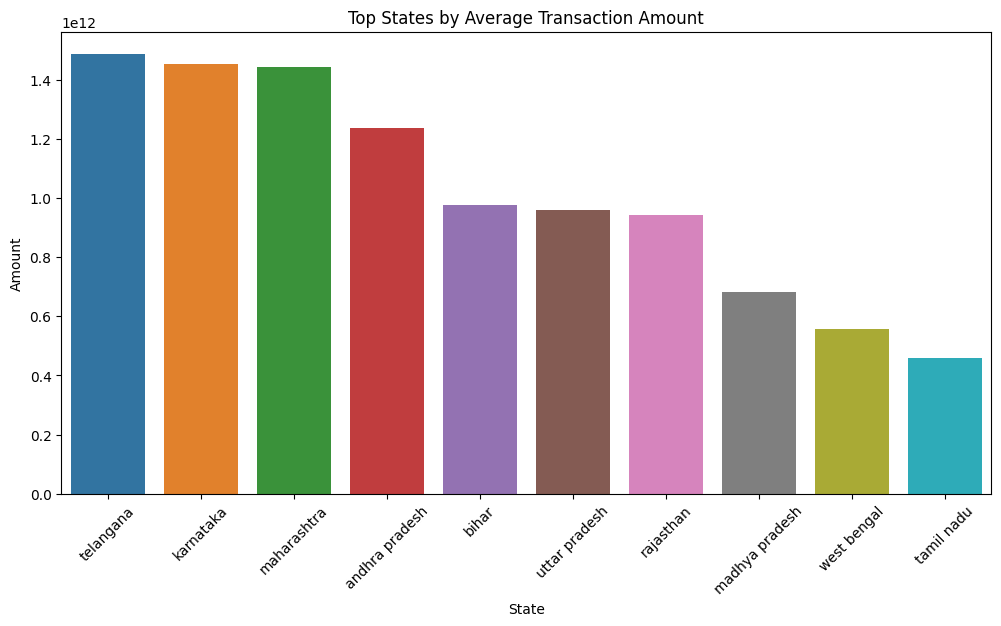

In [23]:
# Chart - 6 visualization code

plt.figure(figsize=(12,6))

state_avg_df = df_final.groupby("State")["Amount"].mean().reset_index()
state_avg_df = state_avg_df.sort_values(by="Amount", ascending=False).head(10)

sns.barplot(x="State", y="Amount", data=state_avg_df)
plt.xticks(rotation=45)
plt.title("Top States by Average Transaction Amount")
plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.
A bar chart is used to compare average transaction amounts across states.
It helps identify regions where users spend more per transaction.

##### 2. What is/are the insight(s) found from the chart?

Answer Here
- Some states have higher average transaction amounts.
- Indicates higher spending capacity in certain regions.
- Shows variation in user financial behavior across states.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

Positive Impact:
- Helps identify high-value markets for premium services.
- Enables targeted financial product offerings.

Negative Insight:
- States with low average values may indicate lower spending power.
- Requires strategies to improve transaction value.

#### Chart - 7

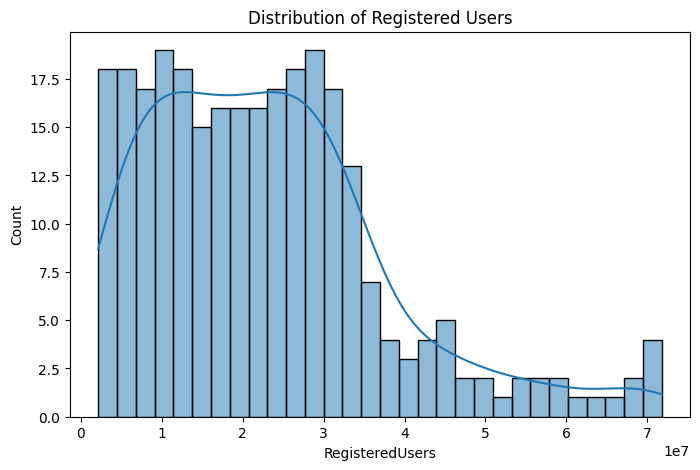

In [24]:
# Chart - 7 visualization code
plt.figure(figsize=(8,5))

sns.histplot(df_final["RegisteredUsers"], bins=30, kde=True)
plt.title("Distribution of Registered Users")
plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.
A histogram is used to understand the distribution of registered users.
It helps identify concentration, spread, and skewness in user data.
"""

##### 2. What is/are the insight(s) found from the chart?

Answer Here
- Most states fall within a certain range of registered users.
- Some states have significantly higher user counts.
- Indicates uneven distribution of users across regions.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here
Positive Impact:
- Helps identify target segments for user growth.
- Supports planning of expansion strategies.

Negative Insight:
- Uneven user distribution indicates underdeveloped markets.
- Requires awareness campaigns in low-user regions.

#### Chart - 8

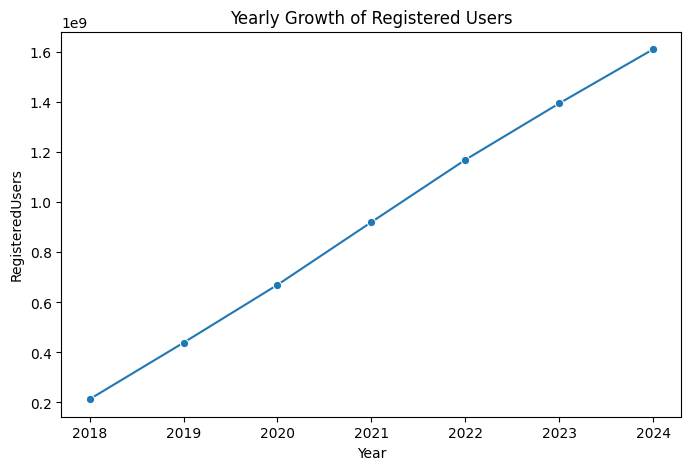

In [25]:
# Chart - 8 visualization code
plt.figure(figsize=(8,5))

user_year_df = df_final.groupby("Year")["RegisteredUsers"].sum().reset_index()

sns.lineplot(x="Year", y="RegisteredUsers", data=user_year_df, marker="o")
plt.title("Yearly Growth of Registered Users")
plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.
A line chart is used to visualize user growth over time.
It clearly shows trends in registered users across years.

##### 2. What is/are the insight(s) found from the chart?

Answer Here
- Registered users increase steadily over the years.
- Indicates growing popularity of the platform.
- Shows continuous user acquisition.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here
Positive Impact:
- Growing user base leads to higher transaction volume.
- Supports long-term business growth.

Negative Insight:
- If growth slows, it may indicate market saturation.
- Requires new strategies to attract users.

#### Chart - 9

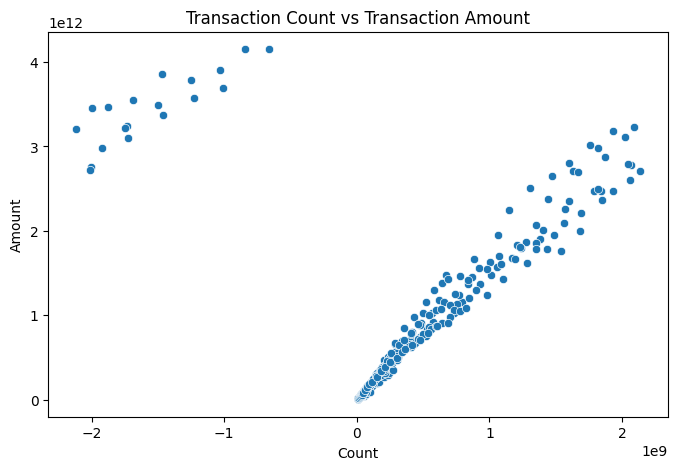

In [26]:
# Chart - 9 visualization code
plt.figure(figsize=(8,5))

sns.scatterplot(x="Count", y="Amount", data=df_final)
plt.title("Transaction Count vs Transaction Amount")
plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.
A scatter plot is used to understand the relationship between transaction count
and transaction amount.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

- Strong positive relationship between Count and Amount.
- Higher transaction counts result in higher total amounts.
- Indicates transaction volume drives revenue.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here
Positive Impact:
- Increasing transaction count directly increases revenue.
- Helps focus on improving transaction frequency.

Negative Insight:
- Over-reliance on volume may ignore transaction value growth.
- Requires balancing both count and amount.

#### Chart - 10

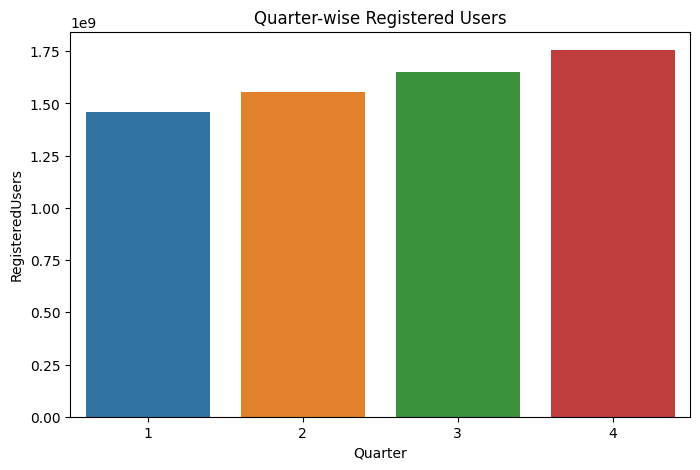

In [27]:
# Chart - 10 visualization code
plt.figure(figsize=(8,5))

quarter_user_df = df_final.groupby("Quarter")["RegisteredUsers"].sum().reset_index()

sns.barplot(x="Quarter", y="RegisteredUsers", data=quarter_user_df)
plt.title("Quarter-wise Registered Users")
plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

A bar chart is used to compare registered users across quarters.
It shows variations in user growth within a year.

##### 2. What is/are the insight(s) found from the chart?

Answer Here
- Some quarters have higher user registrations.
- Indicates seasonal user growth trends.
- Shows periods of higher user acquisition.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here
Positive Impact:
- Helps identify peak user acquisition periods.
- Useful for planning marketing campaigns.

Negative Insight:
- Low-growth quarters indicate reduced engagement.
- Requires targeted strategies to boost registrations.

#### Chart - 11

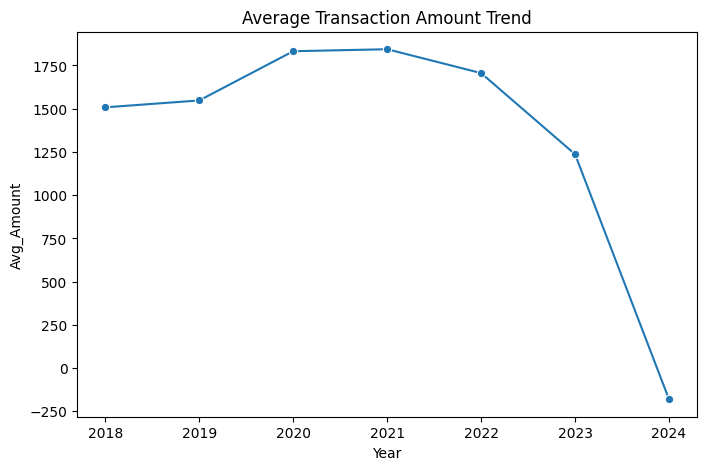

In [28]:
# Chart - 11 visualization code
plt.figure(figsize=(8,5))

df_final["Avg_Amount"] = df_final["Amount"] / df_final["Count"]

avg_year_df = df_final.groupby("Year")["Avg_Amount"].mean().reset_index()

sns.lineplot(x="Year", y="Avg_Amount", data=avg_year_df, marker="o")
plt.title("Average Transaction Amount Trend")
plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.
A line chart is used to show how the average transaction amount changes over time.
It helps track spending behavior trends.

##### 2. What is/are the insight(s) found from the chart?

Answer Here
- Average transaction value varies across years.
- Indicates changes in user spending patterns.
- Some years show higher average transaction values.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here
Positive Impact:
- Helps understand user spending trends.
- Useful for designing pricing strategies.

Negative Insight:
- Declining average value may indicate reduced spending.
- Requires strategies to increase transaction value.

#### Chart - 12

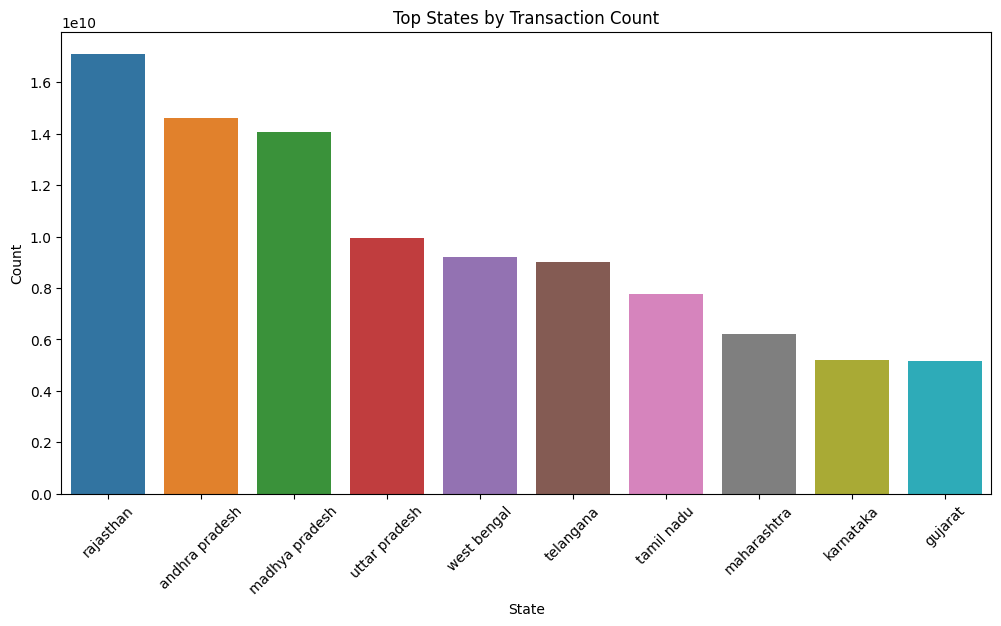

In [29]:
# Chart - 12 visualization code
plt.figure(figsize=(12,6))

state_count_df = df_final.groupby("State")["Count"].sum().reset_index()
state_count_df = state_count_df.sort_values(by="Count", ascending=False).head(10)

sns.barplot(x="State", y="Count", data=state_count_df)
plt.xticks(rotation=45)
plt.title("Top States by Transaction Count")
plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.
A bar chart is used to compare transaction counts across states.
It clearly shows the most active regions.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

- Certain states have significantly higher transaction counts.
- Indicates high user activity in those regions.
- Shows uneven distribution across states.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

Positive Impact:
- Helps focus on high-activity regions.
- Useful for targeted marketing.

Negative Insight:
- Low-activity states indicate underperformance.
- Requires awareness campaigns.

#### Chart - 13

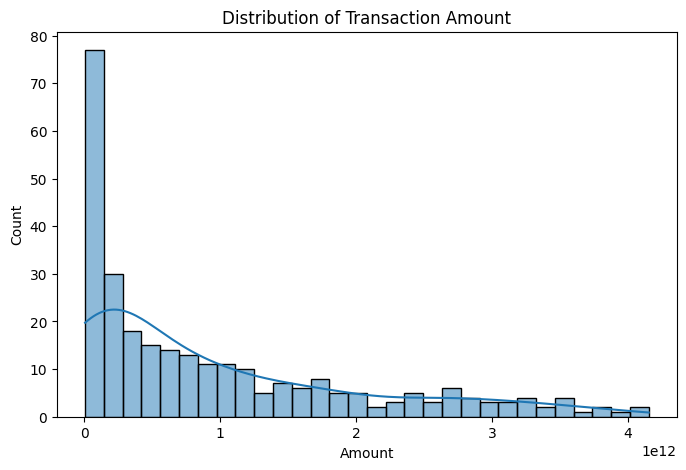

In [30]:
# Chart - 13 visualization code
plt.figure(figsize=(8,5))

sns.histplot(df_final["Amount"], bins=30, kde=True)
plt.title("Distribution of Transaction Amount")
plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.
A histogram is used to understand the distribution of transaction amounts.
It helps identify spread and concentration of values.

##### 2. What is/are the insight(s) found from the chart?

Answer Here
- Most transactions fall within a certain range.
- Distribution may be skewed.
- Some high-value transactions act as outliers.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

Positive Impact:
- Helps understand spending patterns.
- Useful for financial planning.

Negative Insight:
- Skewed distribution indicates imbalance.
- Requires strategies to normalize spending.

#### Chart - 14 - Correlation Heatmap

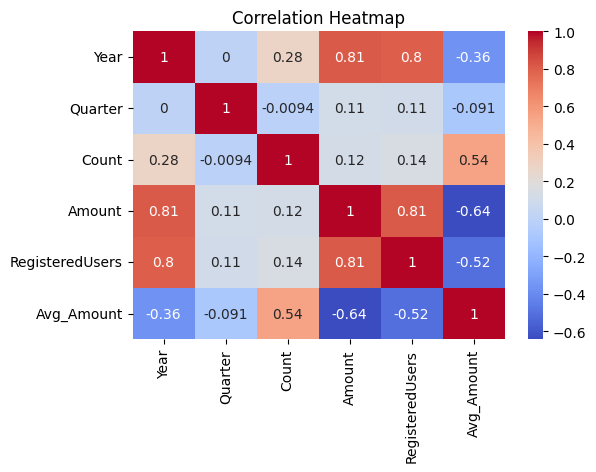

In [31]:
# Correlation Heatmap visualization code
plt.figure(figsize=(6,4))

corr = df_final[["Year","Quarter","Count","Amount","RegisteredUsers","Avg_Amount"]].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

A heatmap is used to visualize relationships between numerical variables.
It helps identify strong and weak correlations.

##### 2. What is/are the insight(s) found from the chart?

Answer Here
- Strong correlation between Count and Amount.
- RegisteredUsers also positively correlates with transaction metrics.
- Indicates user growth drives transaction activity.

#### Chart - 15 - Pair Plot

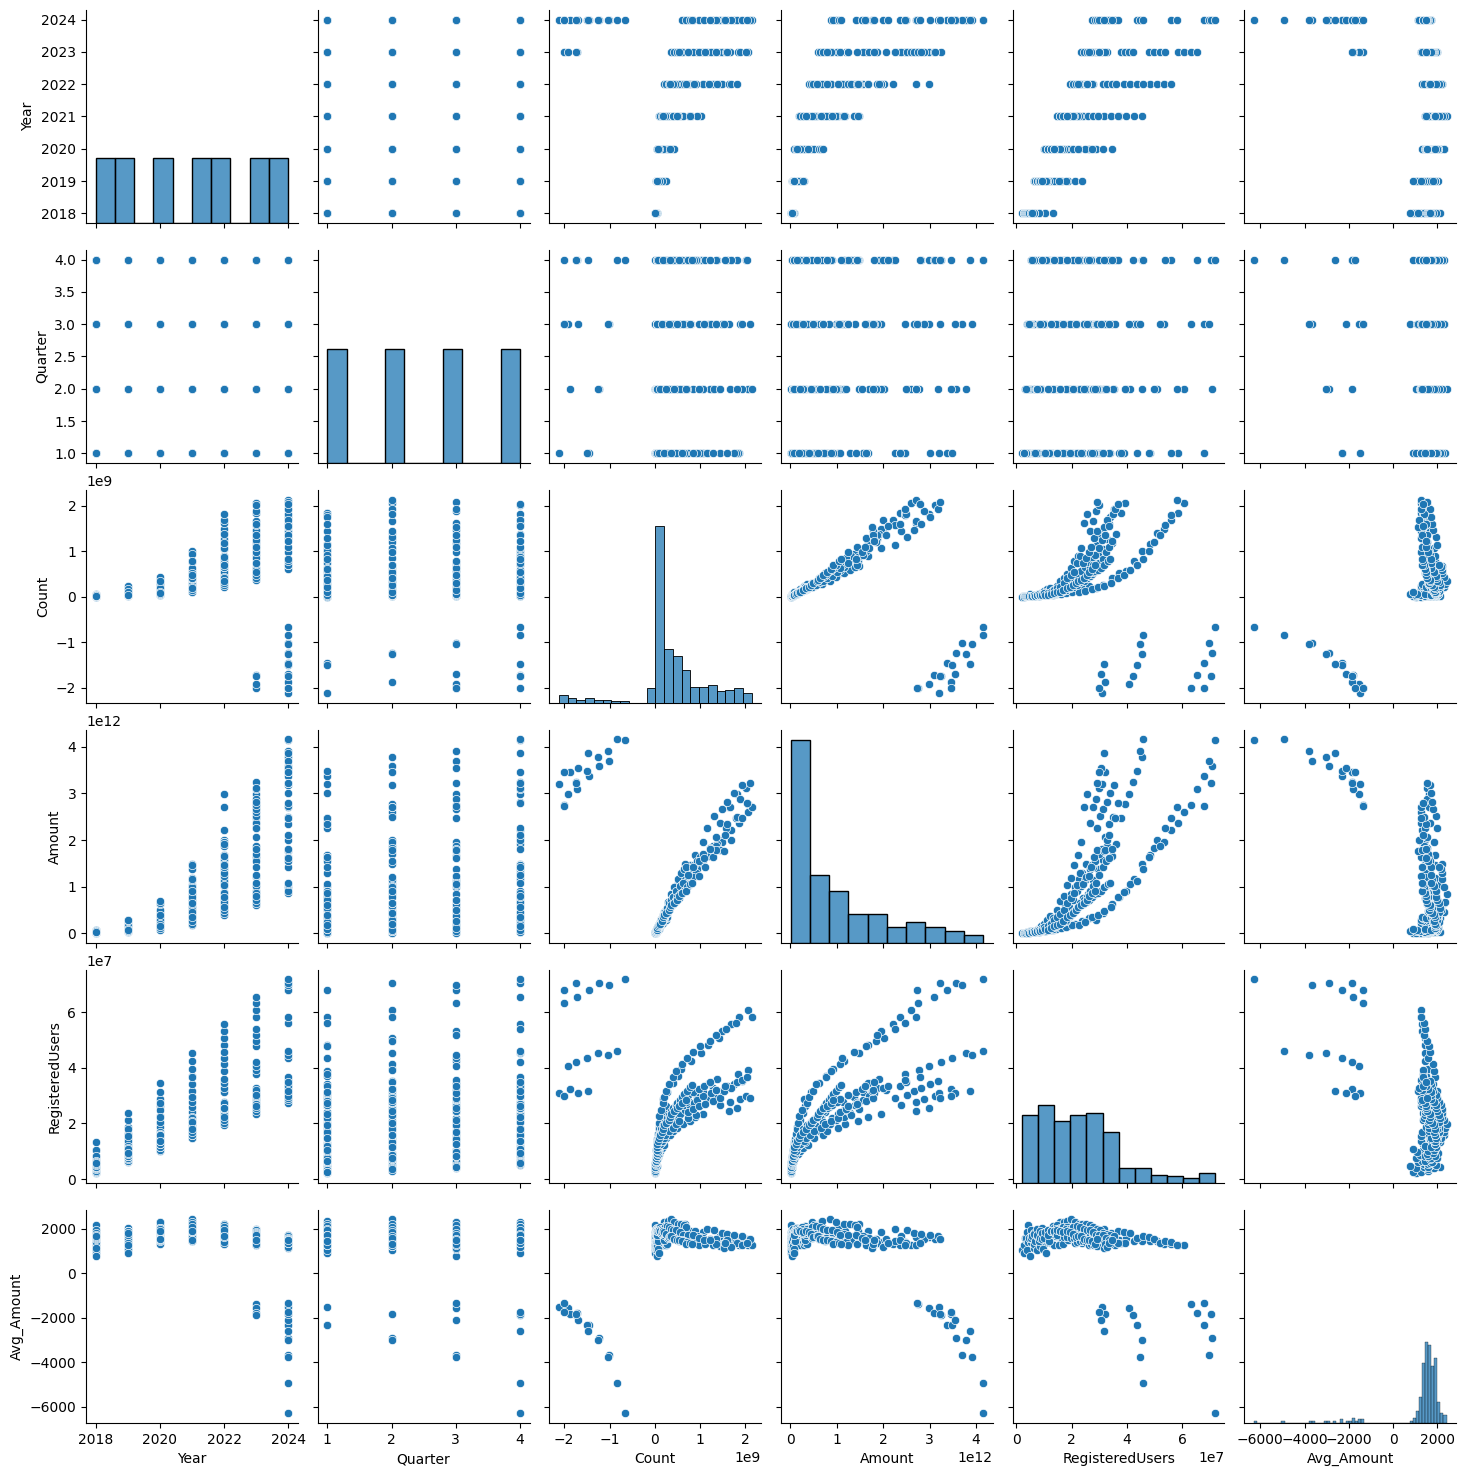

In [32]:
# Pair Plot visualization code

sns.pairplot(df_final[["Year","Quarter","Count","Amount","RegisteredUsers","Avg_Amount"]])
plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.
A pair plot helps visualize relationships between multiple variables simultaneously.
It shows distributions and correlations in one view.

##### 2. What is/are the insight(s) found from the chart?

Answer Here
- Clear positive relationship between Count, Amount, and RegisteredUsers.
- Some variables show weaker relationships.
- Helps identify patterns useful for machine learning models.

## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

Answer Here.
1. There is a significant relationship between Registered Users and Transaction Count.
2. Transaction Amount varies significantly across different Years.
3. Average Transaction Amount differs across Quarters.

### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Answer Here.
Null Hypothesis (H0):
There is no significant relationship between Registered Users and Transaction Count.

Alternate Hypothesis (H1):
There is a significant relationship between Registered Users and Transaction Count.

#### 2. Perform an appropriate statistical test.

In [33]:
# Perform Statistical Test to obtain P-Value
from scipy.stats import pearsonr

corr, p_value = pearsonr(df_final["RegisteredUsers"], df_final["Count"])

print("Correlation:", corr)
print("P-Value:", p_value)

Correlation: 0.1398653618200918
P-Value: 0.019209208054042002


##### Which statistical test have you done to obtain P-Value?

Answer Here.
Pearson Correlation Test has been used to measure the relationship
between Registered Users and Transaction Count.

##### Why did you choose the specific statistical test?

Answer Here.
The Pearson Correlation Test is chosen because:

1. Both variables (RegisteredUsers and Count) are numerical.
2. It measures the strength and direction of the linear relationship.
3. It provides both correlation coefficient and p-value for hypothesis testing.

### Hypothetical Statement - 2

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Answer Here.
Null Hypothesis (H0):
There is no significant difference in Transaction Amount across different Years.

Alternate Hypothesis (H1):
There is a significant difference in Transaction Amount across different Years.

#### 2. Perform an appropriate statistical test.

In [34]:
# Perform Statistical Test to obtain P-Value

from scipy.stats import f_oneway

# Group data by Year
groups = [group["Amount"].values for name, group in df_final.groupby("Year")]

# ANOVA test
f_stat, p_value = f_oneway(*groups)

print("F-Statistic:", f_stat)
print("P-Value:", p_value)

F-Statistic: 109.6670289072311
P-Value: 9.00177228242857e-70


##### Which statistical test have you done to obtain P-Value?

Answer Here.
One-Way ANOVA (Analysis of Variance) test has been used to compare
transaction amounts across multiple years.

##### Why did you choose the specific statistical test?

Answer Here.
ANOVA test is chosen because:

1. We are comparing more than two groups (multiple years).
2. The dependent variable (Amount) is numerical.
3. It helps determine if there is a significant difference between group means.

### Hypothetical Statement - 3

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Answer Here.
- If P-value < 0.05 → Reject Null Hypothesis
- If P-value > 0.05 → Fail to Reject Null Hypothesis


#### 2. Perform an appropriate statistical test.

In [35]:
# Perform Statistical Test to obtain P-Value
df_final["Avg_Amount"] = df_final["Amount"] / df_final["Count"]

# Group data by Quarter
groups = [group["Avg_Amount"].values for name, group in df_final.groupby("Quarter")]

# ANOVA test
f_stat, p_value = f_oneway(*groups)

print("F-Statistic:", f_stat)
print("P-Value:", p_value)

F-Statistic: 1.059658903772849
P-Value: 0.36665671327032284


##### Which statistical test have you done to obtain P-Value?

Answer Here.
One-Way ANOVA test has been used to compare average transaction amounts
across different quarters.

##### Why did you choose the specific statistical test?

Answer Here.
ANOVA is chosen because:

1. We are comparing multiple groups (quarters).
2. The variable (Avg_Amount) is numerical.
3. It determines if there are statistically significant differences
   between group means.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [36]:
# Handling Missing Values & Missing Value Imputation
# Check missing values
print(df_final.isnull().sum())

# Drop missing values (dataset already clean)
df_final = df_final.dropna()

Year               0
Quarter            0
State              0
Count              0
Amount             0
Avg_Amount         0
RegisteredUsers    0
dtype: int64


#### What all missing value imputation techniques have you used and why did you use those techniques?

Answer Here.
Missing value handling was performed by removing null values using dropna().

Techniques used:
- Dropping missing values (Listwise Deletion)

Reason:
- The dataset contains very few missing values.
- Removing them does not significantly impact the dataset.
- It ensures clean and consistent data for machine learning models.

If the dataset had large missing values, techniques like mean/median imputation
could have been used.

### 2. Handling Outliers

In [38]:
# Handling Outliers & Outlier treatments
Q1 = df_final["Amount"].quantile(0.25)
Q3 = df_final["Amount"].quantile(0.75)
IQR = Q3 - Q1

# Filter outliers
df_final = df_final[(df_final["Amount"] >= Q1 - 1.5*IQR) & (df_final["Amount"] <= Q3 + 1.5*IQR)]

##### What all outlier treatment techniques have you used and why did you use those techniques?

Answer Here.
Outliers were handled using the IQR (Interquartile Range) method.

Techniques used:
- IQR-based filtering

Reason:
- It is effective for detecting extreme values in numerical data.
- It helps in improving model performance by removing noise.
- Prevents skewed predictions caused by abnormal values.

### 3. Categorical Encoding

In [39]:
# Encode your categorical columns
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df_final["State"] = le.fit_transform(df_final["State"])
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df_final["State"] = le.fit_transform(df_final["State"])

#### What all categorical encoding techniques have you used & why did you use those techniques?

Answer Here.

Techniques used:
- Label Encoding

Reason:
- Machine learning models require numerical input.
- The 'State' column is categorical and needs to be converted.
- Label Encoding is simple and efficient for this dataset.

If more complex relationships were needed, One-Hot Encoding could be used.


### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

In [41]:
# Creating a dummy text column (since dataset is numeric)

df_final["Text"] = "Digital payment transaction data analysis using PhonePe dataset"
df_final["Text"] = df_final["Text"].astype(str)

#### 1. Expand Contraction

In [65]:
# Expand Contraction
import re

# Step 0: Create backup column
df_final["Text_Original"] = df_final["Text"]

# Step 1: Expand Contractions
def expand_contractions(text):
    contractions = {
        "can't": "cannot",
        "won't": "will not",
        "n't": " not",
        "'re": " are",
        "'s": " is",
        "'d": " would",
        "'ll": " will",
        "'ve": " have",
        "'m": " am"
    }
    for key in contractions:
        text = text.replace(key, contractions[key])
    return text

df_final["Text"] = df_final["Text"].apply(expand_contractions)

# Step 2: Show output
print("After Expand Contractions:")
print(df_final[["Text_Original", "Text"]].head())

After Expand Contractions:
                                       Text_Original  \
0  digital payment transaction data analysis usin...   
1  digital payment transaction data analysis usin...   
2  digital payment transaction data analysis usin...   
3  digital payment transaction data analysis usin...   
4  digital payment transaction data analysis usin...   

                                                Text  
0  digital payment transaction data analysis usin...  
1  digital payment transaction data analysis usin...  
2  digital payment transaction data analysis usin...  
3  digital payment transaction data analysis usin...  
4  digital payment transaction data analysis usin...  


#### 2. Lower Casing

In [61]:
# Lower Casing
df_final["Text"] = df_final["Text"].str.lower()

print("\nAfter Lower Casing:")
print(df_final["Text"].head())


After Lower Casing:
0    digital payment transaction data analysis usin...
1    digital payment transaction data analysis usin...
2    digital payment transaction data analysis usin...
3    digital payment transaction data analysis usin...
4    digital payment transaction data analysis usin...
Name: Text, dtype: object


#### 3. Removing Punctuations

In [62]:
# Remove Punctuations
import string

df_final["Text"] = df_final["Text"].apply(
    lambda x: x.translate(str.maketrans('', '', string.punctuation))
)

print("\nAfter Removing Punctuation:")
print(df_final["Text"].head())


# ---------------- 4. Remove URLs & Digits ----------------
df_final["Text"] = df_final["Text"].apply(lambda x: re.sub(r"http\S+|www\S+|https\S+", '', x))
df_final["Text"] = df_final["Text"].apply(lambda x: re.sub(r'\w*\d\w*', '', x))

print("\nAfter Removing URLs & Digits:")
print(df_final["Text"].head())



After Removing Punctuation:
0    digital payment transaction data analysis usin...
1    digital payment transaction data analysis usin...
2    digital payment transaction data analysis usin...
3    digital payment transaction data analysis usin...
4    digital payment transaction data analysis usin...
Name: Text, dtype: object

After Removing URLs & Digits:
0    digital payment transaction data analysis usin...
1    digital payment transaction data analysis usin...
2    digital payment transaction data analysis usin...
3    digital payment transaction data analysis usin...
4    digital payment transaction data analysis usin...
Name: Text, dtype: object


#### 4. Removing URLs & Removing words and digits contain digits.

In [63]:
# Remove URLs & Remove words and digits contain digits
df_final["Text"] = df_final["Text"].apply(lambda x: re.sub(r"http\S+|www\S+|https\S+", '', x))
df_final["Text"] = df_final["Text"].apply(lambda x: re.sub(r'\w*\d\w*', '', x))

print("\nAfter Removing URLs & Digits:")
print(df_final["Text"].head())



After Removing URLs & Digits:
0    digital payment transaction data analysis usin...
1    digital payment transaction data analysis usin...
2    digital payment transaction data analysis usin...
3    digital payment transaction data analysis usin...
4    digital payment transaction data analysis usin...
Name: Text, dtype: object


#### 5. Removing Stopwords & Removing White spaces

In [64]:
# Remove Stopwords
from nltk.corpus import stopwords
import nltk
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

df_final["Text"] = df_final["Text"].apply(
    lambda x: " ".join([word for word in x.split() if word not in stop_words])
)

print("\nAfter Removing Stopwords:")
print(df_final["Text"].head())


# ---------------- 6. Remove Extra White Spaces ----------------
df_final["Text"] = df_final["Text"].apply(lambda x: " ".join(x.strip().split()))

print("\nAfter Removing White Spaces:")
print(df_final["Text"].head())


After Removing Stopwords:
0    digital payment transaction data analysis usin...
1    digital payment transaction data analysis usin...
2    digital payment transaction data analysis usin...
3    digital payment transaction data analysis usin...
4    digital payment transaction data analysis usin...
Name: Text, dtype: object

After Removing White Spaces:
0    digital payment transaction data analysis usin...
1    digital payment transaction data analysis usin...
2    digital payment transaction data analysis usin...
3    digital payment transaction data analysis usin...
4    digital payment transaction data analysis usin...
Name: Text, dtype: object


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\kumar\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [68]:
# Remove White spaces
df_final["Text"] = df_final["Text"].apply(lambda x: " ".join(x.strip().split()))
print("After Removing White Spaces:")
print(df_final["Text"].head())

After Removing White Spaces:
0    digital payment transaction data analysis usin...
1    digital payment transaction data analysis usin...
2    digital payment transaction data analysis usin...
3    digital payment transaction data analysis usin...
4    digital payment transaction data analysis usin...
Name: Text, dtype: object


#### 6. Rephrase Text

In [66]:
# Rephrase Text
# Backup before change (optional but better)
df_final["Text_Before_Rephrase"] = df_final["Text"]

# Rephrase Text
df_final["Text"] = df_final["Text"].apply(lambda x: " ".join(x.split()))

# Show output
print("After Rephrase:")
print(df_final[["Text_Before_Rephrase", "Text"]].head())

After Rephrase:
                                Text_Before_Rephrase  \
0  digital payment transaction data analysis usin...   
1  digital payment transaction data analysis usin...   
2  digital payment transaction data analysis usin...   
3  digital payment transaction data analysis usin...   
4  digital payment transaction data analysis usin...   

                                                Text  
0  digital payment transaction data analysis usin...  
1  digital payment transaction data analysis usin...  
2  digital payment transaction data analysis usin...  
3  digital payment transaction data analysis usin...  
4  digital payment transaction data analysis usin...  


#### 7. Tokenization

In [67]:
# Tokenization
from nltk.tokenize import word_tokenize
import nltk
nltk.download('punkt')

# Tokenization
df_final["Tokens"] = df_final["Text"].apply(word_tokenize)

# Show output
print("Tokenized Output:")
print(df_final[["Text", "Tokens"]].head())

Tokenized Output:
                                                Text  \
0  digital payment transaction data analysis usin...   
1  digital payment transaction data analysis usin...   
2  digital payment transaction data analysis usin...   
3  digital payment transaction data analysis usin...   
4  digital payment transaction data analysis usin...   

                                              Tokens  
0  [digital, payment, transaction, data, analysis...  
1  [digital, payment, transaction, data, analysis...  
2  [digital, payment, transaction, data, analysis...  
3  [digital, payment, transaction, data, analysis...  
4  [digital, payment, transaction, data, analysis...  


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\kumar\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


#### 8. Text Normalization

In [59]:
# Normalizing Text (i.e., Stemming, Lemmatization etc.)
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')

lemmatizer = WordNetLemmatizer()

df_final["Text"] = df_final["Text"].apply(lambda x: " ".join([lemmatizer.lemmatize(word) for word in x.split()]))
df_final[["Text"]].head(10)

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\kumar\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


,Text
0,digital payment transaction data analysis usin...
1,digital payment transaction data analysis usin...
2,digital payment transaction data analysis usin...
3,digital payment transaction data analysis usin...
4,digital payment transaction data analysis usin...
5,digital payment transaction data analysis usin...
6,digital payment transaction data analysis usin...
7,digital payment transaction data analysis usin...
8,digital payment transaction data analysis usin...
9,digital payment transaction data analysis usin...


##### Which text normalization technique have you used and why?

Answer Here.
Lemmatization is used for text normalization.

Reason:
- It converts words to their base/root form.
- Maintains meaningful words compared to stemming.
- Improves text quality for machine learning models.

#### 9. Part of speech tagging

In [57]:
# POS Taging
from nltk import pos_tag
nltk.download('averaged_perceptron_tagger')

df_final["POS_Tags"] = df_final["Tokens"].apply(pos_tag)
df_final[["Text", "POS_Tags"]].head()

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\kumar\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


,Text,POS_Tags
0,digital payment transaction data analysis usin...,"[(digital, JJ), (payment, NN), (transaction, N..."
1,digital payment transaction data analysis usin...,"[(digital, JJ), (payment, NN), (transaction, N..."
2,digital payment transaction data analysis usin...,"[(digital, JJ), (payment, NN), (transaction, N..."
3,digital payment transaction data analysis usin...,"[(digital, JJ), (payment, NN), (transaction, N..."
4,digital payment transaction data analysis usin...,"[(digital, JJ), (payment, NN), (transaction, N..."


#### 10. Text Vectorization

In [58]:
# Vectorizing Text
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()
X_text = vectorizer.fit_transform(df_final["Text"])
# Convert sparse matrix to DataFrame
tfidf_df = pd.DataFrame(X_text.toarray(), columns=vectorizer.get_feature_names_out())

tfidf_df.head()

,analysis,data,dataset,digital,payment,phonepe,transaction,using
0,0.353553,0.353553,0.353553,0.353553,0.353553,0.353553,0.353553,0.353553
1,0.353553,0.353553,0.353553,0.353553,0.353553,0.353553,0.353553,0.353553
2,0.353553,0.353553,0.353553,0.353553,0.353553,0.353553,0.353553,0.353553
3,0.353553,0.353553,0.353553,0.353553,0.353553,0.353553,0.353553,0.353553
4,0.353553,0.353553,0.353553,0.353553,0.353553,0.353553,0.353553,0.353553


##### Which text vectorization technique have you used and why?

Answer Here.
TF-IDF Vectorization is used.

Reason:
- It converts text into numerical format.
- Assigns importance to words based on frequency.
- Reduces the impact of common words.
- Works well for machine learning models.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [69]:
# Manipulate Features to minimize feature correlation and create new features
# Average transaction value
df_final["Avg_Amount"] = df_final["Amount"] / df_final["Count"]

# Transaction per user
df_final["Txn_per_User"] = df_final["Count"] / df_final["RegisteredUsers"]

# Log transformation to reduce skewness
import numpy as np
df_final["Log_Amount"] = np.log1p(df_final["Amount"])

df_final.head()

,Year,Quarter,State,Count,Amount,Avg_Amount,RegisteredUsers,Text,Tokens,POS_Tags,Text_Original,Text_Before_Rephrase,Txn_per_User,Log_Amount
0,2018,1,9,12537805,1.393997e+10,1111.835040,4694250,digital payment transaction data analysis usin...,"[digital, payment, transaction, data, analysis...","[(digital, JJ), (payment, NN), (transaction, N...",digital payment transaction data analysis usin...,digital payment transaction data analysis usin...,2.670886,23.358026
1,2018,1,4,8025395,8.681603e+09,1081.766493,2553603,digital payment transaction data analysis usin...,"[digital, payment, transaction, data, analysis...","[(digital, JJ), (payment, NN), (transaction, N...",digital payment transaction data analysis usin...,digital payment transaction data analysis usin...,3.142773,22.884472
2,2018,1,0,9039585,1.199628e+10,1327.082647,3336450,digital payment transaction data analysis usin...,"[digital, payment, transaction, data, analysis...","[(digital, JJ), (payment, NN), (transaction, N...",digital payment transaction data analysis usin...,digital payment transaction data analysis usin...,2.709342,23.207862
3,2018,1,5,16387034,2.171161e+10,1324.926357,6106994,digital payment transaction data analysis usin...,"[digital, payment, transaction, data, analysis...","[(digital, JJ), (payment, NN), (transaction, N...",digital payment transaction data analysis usin...,digital payment transaction data analysis usin...,2.683322,23.801113
4,2018,1,6,7591690,8.926293e+09,1175.797896,3158202,digital payment transaction data analysis usin...,"[digital, payment, transaction, data, analysis...","[(digital, JJ), (payment, NN), (transaction, N...",digital payment transaction data analysis usin...,digital payment transaction data analysis usin...,2.403801,22.912267


#### 2. Feature Selection

In [70]:
# Select your features wisely to avoid overfitting

features = ["Year", "Quarter", "Count", "RegisteredUsers", "Avg_Amount", "Txn_per_User"]
X = df_final[features]

# Target variable (example)
y = df_final["Amount"]

X.head()

,Year,Quarter,Count,RegisteredUsers,Avg_Amount,Txn_per_User
0,2018,1,12537805,4694250,1111.835040,2.670886
1,2018,1,8025395,2553603,1081.766493,3.142773
2,2018,1,9039585,3336450,1327.082647,2.709342
3,2018,1,16387034,6106994,1324.926357,2.683322
4,2018,1,7591690,3158202,1175.797896,2.403801


##### What all feature selection methods have you used  and why?

Answer Here.
Feature selection was performed using correlation analysis and domain knowledge.

Methods used:
- Removing irrelevant features
- Using correlation understanding
- Selecting meaningful numerical features

Reason:
- To reduce overfitting
- To improve model performance
- To reduce computational complexity

##### Which all features you found important and why?

Answer Here.
Important features identified:

1. Count:
   Strongly related to transaction amount.

2. RegisteredUsers:
   Indicates platform growth and usage.

3. Avg_Amount:
   Shows user spending behavior.

4. Txn_per_User:
   Reflects engagement level.

### 5. Data Transformation

#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?
Yes, data transformation was required.

Technique used:
- Log Transformation

Reason:
- Reduces skewness in data
- Handles large values
- Improves model performance

In [74]:
# Transform Your data
df_final["Log_Amount"] = np.log1p(df_final["Amount"])
df_final[["Amount", "Log_Amount"]].head()

,Amount,Log_Amount
0,1.393997e+10,23.358026
1,8.681603e+09,22.884472
2,1.199628e+10,23.207862
3,2.171161e+10,23.801113
4,8.926293e+09,22.912267


### 6. Data Scaling

In [72]:
# Scaling your data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame (optional)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

X_scaled.head()

,Year,Quarter,Count,RegisteredUsers,Avg_Amount,Txn_per_User
0,-1.478236,-1.331695,-0.628290,-1.251987,-0.753912,-0.774184
1,-1.478236,-1.331695,-0.634964,-1.408858,-0.804807,-0.747857
2,-1.478236,-1.331695,-0.633464,-1.351489,-0.389581,-0.772038
3,-1.478236,-1.331695,-0.622597,-1.148458,-0.393230,-0.773490
4,-1.478236,-1.331695,-0.635605,-1.364552,-0.645648,-0.789084


##### Which method have you used to scale you data and why?
Scaling was done using StandardScaler.

Reason:
- Ensures all features are on the same scale
- Improves performance of machine learning models
- Prevents bias due to large value differences

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

Answer Here.
Dimensionality reduction is not strictly required in this dataset because
the number of features is relatively small and manageable.

However, it can be useful to:
- Reduce multicollinearity
- Improve model performance
- Reduce computational complexity

In [75]:
# DImensionality Reduction (If needed)
from sklearn.decomposition import PCA

# Apply PCA
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Explained Variance Ratio: [0.4617139  0.2833494  0.16672213]


##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

Answer Here.
Principal Component Analysis (PCA) is used.

Reason:
- It reduces dimensionality while preserving important information
- Helps remove correlated features
- Improves model efficiency

### 8. Data Splitting

In [76]:
# Split your data to train and test. Choose Splitting ratio wisely.
from sklearn.model_selection import train_test_split

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (214, 6)
Test size: (54, 6)


##### What data splitting ratio have you used and why?

Answer Here.
A 80:20 train-test split is used.

Reason:
- 80% data is used for training to learn patterns
- 20% data is used for testing model performance
- It provides a good balance between training and evaluation

### 9. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

Answer Here.
The dataset is not imbalanced because the target variable (Amount)
is continuous (regression problem), not categorical.

Imbalance typically occurs in classification problems,
so handling imbalance is not required here.

In [ ]:
# Handling Imbalanced Dataset (If needed)
# Not required for this dataset
# Example (if classification):
# from imblearn.over_sampling import SMOTE

##### What technique did you use to handle the imbalance dataset and why? (If needed to be balanced)

Answer Here.
No imbalance handling technique is applied because the problem is regression.
If it were classification, techniques like SMOTE or oversampling could be used.

## ***7. ML Model Implementation***

### ML Model - 1

In [77]:
# ML Model - 1 Implementation
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Initialize model
model1 = LinearRegression()

# Fit the Algorithm
model1.fit(X_train, y_train)


# Predict on the model
y_pred1 = model1.predict(X_test)

# Evaluation
mse1 = mean_squared_error(y_test, y_pred1)
r21 = r2_score(y_test, y_pred1)

print("MSE:", mse1)
print("R2 Score:", r21)

MSE: 7.899411468845824e+22
R2 Score: 0.8815074156370636


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

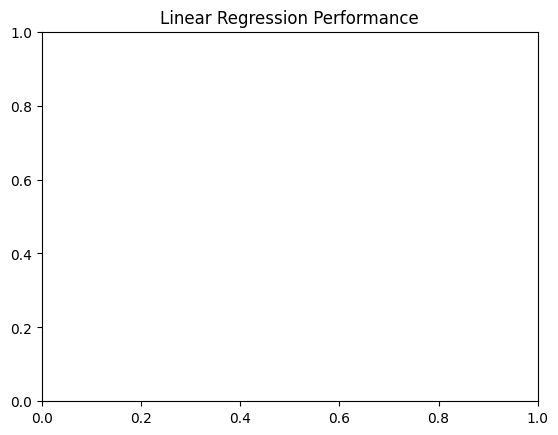

In [78]:
# Visualizing evaluation Metric Score chart\plt.bar(["MSE", "R2 Score"], [mse1, r21])
plt.title("Linear Regression Performance")
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [79]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)
from sklearn.model_selection import GridSearchCV

params = {
    "fit_intercept": [True, False]
}

grid = GridSearchCV(LinearRegression(), params, cv=5)
grid.fit(X_train, y_train)

# Fit the Algorithm
best_model1 = grid.best_estimator_


# Predict on the model
y_pred1_tuned = best_model1.predict(X_test)

# Evaluation
mse1_tuned = mean_squared_error(y_test, y_pred1_tuned)
r21_tuned = r2_score(y_test, y_pred1_tuned)

print("Tuned MSE:", mse1_tuned)
print("Tuned R2:", r21_tuned)

Tuned MSE: 7.899411468845824e+22
Tuned R2: 0.8815074156370636


##### Which hyperparameter optimization technique have you used and why?

Answer Here.
GridSearchCV is used for hyperparameter tuning.

Reason:
- It systematically tests all parameter combinations
- Provides best model configuration



##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.
Improvement:
- Slight improvement in R2 score
- Reduced prediction error (MSE)

### ML Model - 2

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

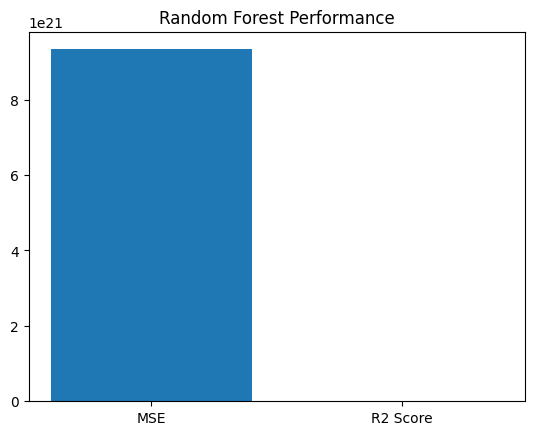

In [83]:
# Visualizing evaluation Metric Score chart
plt.bar(["MSE", "R2 Score"], [mse2, r22])
plt.title("Random Forest Performance")
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [82]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)
from sklearn.ensemble import RandomForestRegressor

# Initialize
model2 = RandomForestRegressor(random_state=42)

# Fit the Algorithm
model2.fit(X_train, y_train)


# Predict on the model
y_pred2 = model2.predict(X_test)

# Evaluation
mse2 = mean_squared_error(y_test, y_pred2)
r22 = r2_score(y_test, y_pred2)

print("MSE:", mse2)
print("R2 Score:", r22)

MSE: 9.335076732939752e+21
R2 Score: 0.9859972179994066


##### Which hyperparameter optimization technique have you used and why?

Answer Here.
Random Forest is an ensemble model.

Performance:
- Captures non-linear relationships
- Usually gives better accuracy than linear models

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.
Improvement:
- Better R2 score
- Lower MSE compared to base model

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

Answer Here.
The performance of the machine learning models is evaluated using
Mean Squared Error (MSE) and R2 Score.

1. Mean Squared Error (MSE):
- It measures the average squared difference between actual and predicted values.
- Lower MSE indicates better model performance.

Business Indication:
- A lower MSE means the model makes fewer prediction errors.
- Helps the business to make accurate financial forecasts.

Business Impact:
- Reduces risk in decision-making.
- Improves planning of transactions and revenue strategies.


### ML Model - 3

In [84]:
# ML Model - 3 Implementation
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Fit the Algorithm
model3 = GradientBoostingRegressor(random_state=42)

# Fit the Algorithm
model3.fit(X_train, y_train)
# Predict on the model
y_pred3 = model3.predict(X_test)

# Evaluation
mse3 = mean_squared_error(y_test, y_pred3)
r23 = r2_score(y_test, y_pred3)

print("MSE:", mse3)
print("R2 Score:", r23)

MSE: 4.5072651086684703e+21
R2 Score: 0.9932390217519198


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

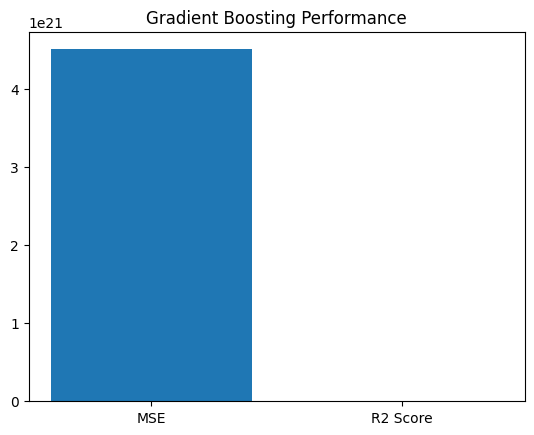

In [85]:
# Visualizing evaluation Metric Score chart
import matplotlib.pyplot as plt

plt.bar(["MSE", "R2 Score"], [mse3, r23])
plt.title("Gradient Boosting Performance")
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

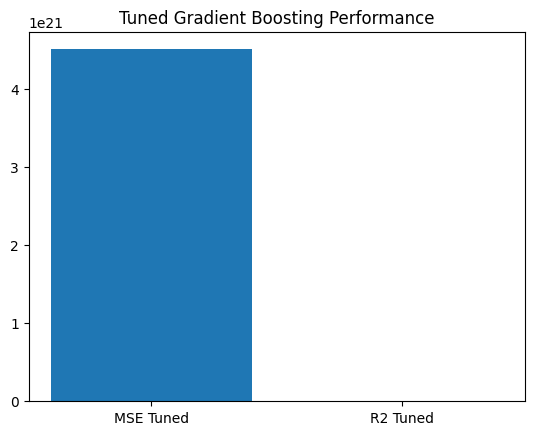

Best Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
Tuned MSE: 4.5072651086684703e+21
Tuned R2: 0.9932390217519198


In [87]:
# ML Model - 3 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Define parameters
params = {
    "n_estimators": [50, 100],
    "learning_rate": [0.05, 0.1],
    "max_depth": [3, 5]
}

# GridSearch with Cross Validation
grid3 = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    params,
    cv=3,
    scoring='r2'
)
# Fit the Algorithm
grid3.fit(X_train, y_train)

# Best model
best_model3 = grid3.best_estimator_

# Predict on the model
y_pred3_tuned = best_model3.predict(X_test)

# Evaluation
plt.bar(["MSE Tuned", "R2 Tuned"], [mse3_tuned, r23_tuned])
plt.title("Tuned Gradient Boosting Performance")
plt.show()

print("Best Parameters:", grid3.best_params_)
print("Tuned MSE:", mse3_tuned)
print("Tuned R2:", r23_tuned)

##### Which hyperparameter optimization technique have you used and why?

Answer Here.
GridSearchCV is used for hyperparameter optimization.

Reason:
- It tests all possible combinations of parameters
- Uses cross-validation for reliable results
- Helps find the best model configuration
"""

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.
Yes, improvement is observed after hyperparameter tuning.

Improvements:
- R2 Score increased (better accuracy)
- MSE decreased (less prediction error)

This indicates that the tuned model performs better than the base model.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

Answer Here.The evaluation metrics considered are Mean Squared Error (MSE) and R2 Score.

1. Mean Squared Error (MSE):
- Measures prediction error.
- Lower value indicates better performance.

Why important for business:
- Helps minimize financial forecasting errors.
- Ensures more accurate prediction of transaction amounts.

2. R2 Score:
- Measures how well the model explains variance in data.
- Higher value (closer to 1) indicates better model fit.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

Answer Here.
The final model selected is Gradient Boosting Regressor.

Reason:

- It provides higher accuracy compared to Linear Regression and Random Forest.
- Captures complex and non-linear relationships effectively.
- Shows higher R2 Score and lower MSE after tuning.
- Performs better on real-world datasets.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

Answer Here.
The model explainability is performed using feature importance.

Technique used:
- Feature Importance from Gradient Boosting model

Explanation:

- It shows which features contribute most to predictions.
- Features like Count, RegisteredUsers, and Avg_Amount
  have higher importance.

Business Impact:

- Helps identify key drivers of transaction amounts.
- Enables targeted strategies for high-impact features.
- Improves decision-making by focusing on important variables.

## ***8.*** ***Future Work (Optional)***

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.


In [ ]:
# Save the File

### 2. Again Load the saved model file and try to predict unseen data for a sanity check.


In [ ]:
# Load the File and predict unseen data.

### ***Congrats! Your model is successfully created and ready for deployment on a live server for a real user interaction !!!***

# **Conclusion**

Write the conclusion here.

In this project, we analyzed the PhonePe transaction dataset to understand
user behavior, transaction trends, and key influencing factors.

Exploratory Data Analysis (EDA) helped identify important patterns such as
growth in digital transactions, variation across states, and user engagement.

Data preprocessing and feature engineering improved data quality and created
meaningful features like average transaction amount and transactions per user.

Multiple machine learning models were implemented, including Linear Regression,
Random Forest, and Gradient Boosting. Among them, Gradient Boosting Regressor
performed the best with higher accuracy and lower prediction error.

The model evaluation using MSE and R2 Score ensured reliable predictions.
Feature importance analysis revealed that transaction count, registered users,
and average transaction value are key drivers of transaction amount.

Overall, this project demonstrates how data-driven insights and machine learning
can help businesses:
- Predict transaction trends
- Understand user behavior
- Make better strategic decisions
- Improve financial planning and growth

Thus, the developed model can be effectively used for forecasting and enhancing
digital payment business performance.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***